<a href="https://colab.research.google.com/github/marius-ne/CIE_ProjectB_Group13/blob/junchao/I-beam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIE 2025/26 RWTH, PROJECT B, GROUP 13
Junchao Yu, Marius Neuhalfen

ToDo:
- Find defective nodes by comparing perfect structure and imperfect structures for all scenarios
- Group defective nodes into regions (arc sections or track sections)
- Predict whether structure is perfect or imperfect
- Predict where the imperfection lies

There are 25.XXX for deformation and 24.XXX for stress

#find I-beam nodes' coordinate

In [1]:
import pandas as pd
from google.colab import files

# 1. 读取您上传的两个文件
# 假设文件名分别为 'nodeExport.txt' 和 'x-beam.txt'
# 如果您的文件名不同，请修改这里
df_all = pd.read_csv('nodeExport.txt', sep='\t')
df_ids = pd.read_csv('I-beam.txt', sep='\t')

# 2. 清理列名（去除多余空格）并统一格式
# 提取坐标文件中的 ID, X, Y, Z (假设列名包含 "Node", "X", "Y", "Z")
df_all = df_all[['Node Number', 'X Location (m)', 'Y Location (m)', 'Z Location (m)']]
df_all.columns = ['Node', 'X', 'Y', 'Z']

# 提取 ID 文件中的 Node 列
df_ids = df_ids[['Node Number']]
df_ids.columns = ['Node']

# 3. 合并数据 (类似于 Excel 的 VLOOKUP)
#只保留 df_ids 中存在的节点
result = pd.merge(df_ids, df_all, on='Node', how='left')

# 4. 保存为 TXT 文件
output_filename = 'matched_nodes_coordinates.txt'
result.to_csv(output_filename, sep='\t', index=False)
print(f"文件已生成: {output_filename}")

# 5. 自动触发下载 (Colab 特有功能)
files.download(output_filename)

文件已生成: matched_nodes_coordinates.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

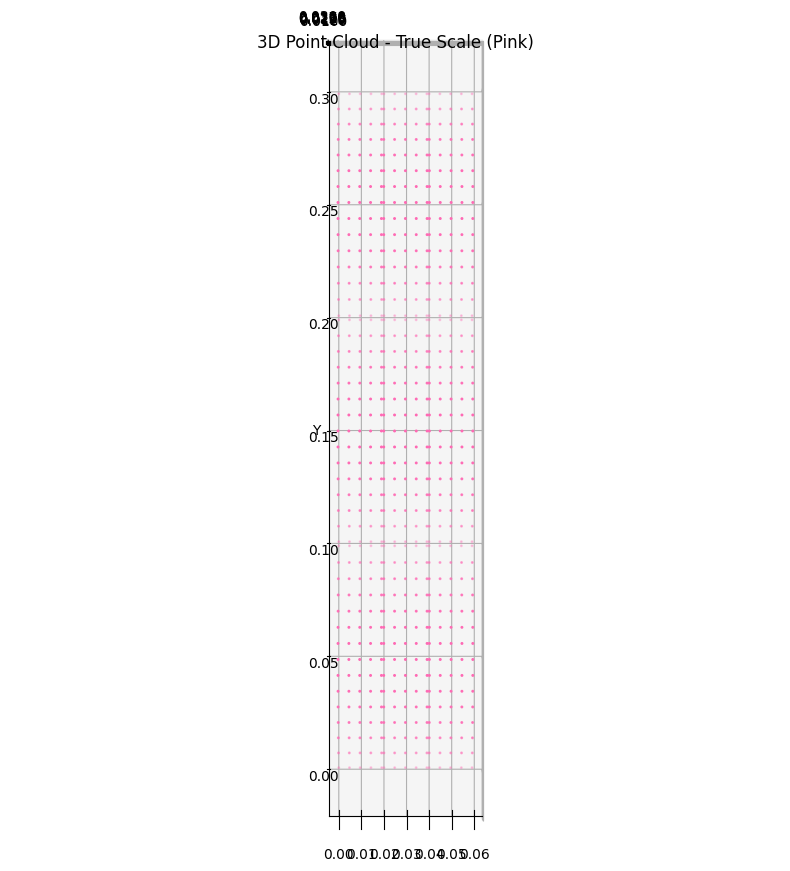

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 读取数据
df = pd.read_csv('matched_nodes_coordinates.txt', sep='\t')

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 计算各轴的范围
x_range = df['X'].max() - df['X'].min()
y_range = df['Y'].max() - df['Y'].min()
z_range = df['Z'].max() - df['Z'].min()

# 设置绘图点，颜色设为粉色 (hotpink)
ax.scatter(df['X'], df['Y'], df['Z'], c='hotpink', marker='.', s=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Point Cloud - True Scale (Pink)')

# 【关键步骤】设置坐标轴比例一致
# 这一步告诉 matplotlib 按照数据的真实比例来显示盒子
ax.set_box_aspect((x_range, y_range, z_range))

# 调整视角 (俯视)
ax.view_init(elev=90, azim=-90)

plt.savefig('3d_point_cloud_pink_true_scale.png')
plt.show()

#classify nodes to every body

1. 正在读取文件...
   坐标文件读取成功: 1215 行
   映射文件读取成功: 25581 行
✅ 合并成功！
   共筛选出节点: 1215
   识别出独立部件: 135 个
2. 正在生成 3D 彩色图像...


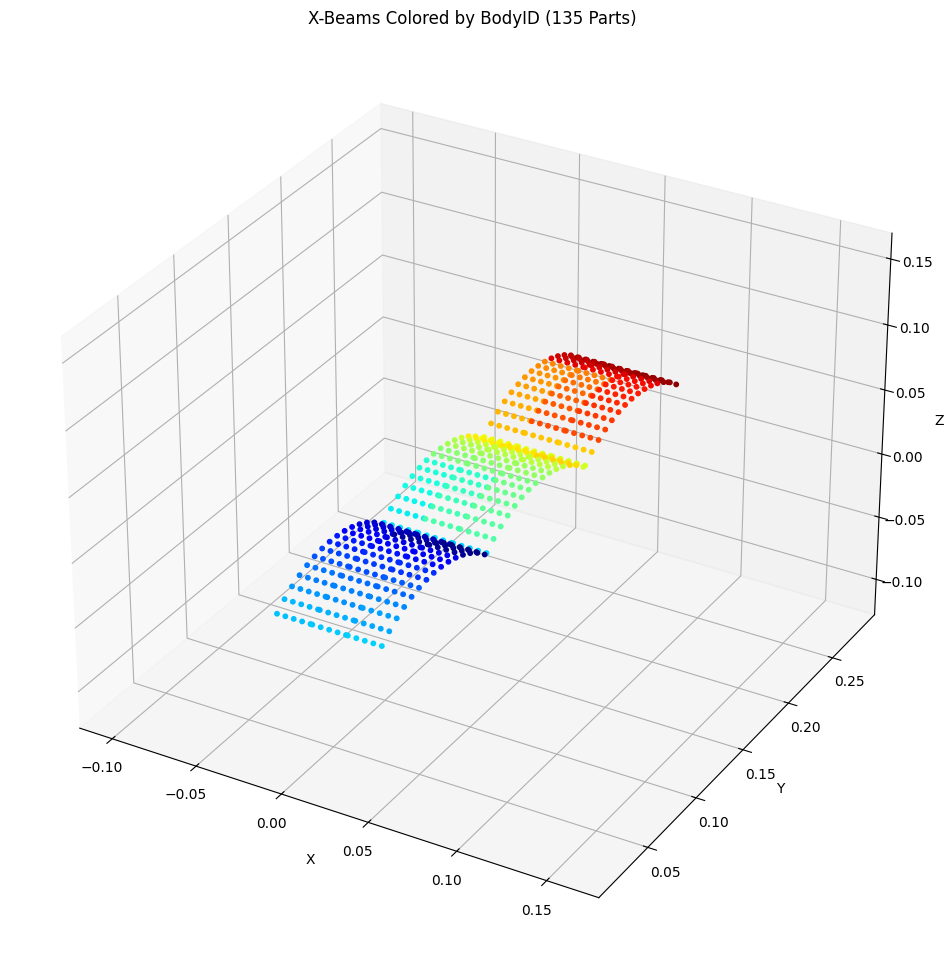

🎉 绘图完成！


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.cm as cm

# ================= 文件名配置 =================
# 请确保左侧文件栏已经上传了这两个文件，名字必须完全一致
coords_file = 'matched_nodes_coordinates.txt'
map_file    = 'node_solid_map.txt'
# ============================================

print("1. 正在读取文件...")

try:
    # --- 读取坐标文件 (Tab分隔) ---
    # 这里的 sep='\t' 很关键，因为 x-beams 文件是用 Tab 隔开的
    df_coords = pd.read_csv(coords_file, sep='\t')
    df_coords.columns = [c.strip() for c in df_coords.columns] # 去除列名空格
    print(f"   坐标文件读取成功: {len(df_coords)} 行")

    # --- 读取映射文件 (逗号分隔) ---
    df_map = pd.read_csv(map_file, sep=',', skipinitialspace=True)
    df_map.columns = [c.strip() for c in df_map.columns]
    print(f"   映射文件读取成功: {len(df_map)} 行")

    # --- 数据类型统一 ---
    # 强制把 Node ID 转为整数，防止匹配失败
    df_coords['Node'] = df_coords['Node'].astype(int)
    df_map['NodeID']  = df_map['NodeID'].astype(int)

    # --- 核心步骤：筛选与合并 ---
    # "inner" 模式表示只保留两个文件中都有的点
    # 这完美实现了您的需求："选出只包含 x-beams 中的点"
    df_merged = pd.merge(df_coords, df_map, left_on='Node', right_on='NodeID', how='inner')

    # 提取 BodyID
    body_col = 'BodyID' # 如果您的文件列名不一样，请在这里修改
    unique_bodies = df_merged[body_col].unique()
    # 去除背景 0 (如果存在)
    unique_bodies = [b for b in unique_bodies if b != 0]

    print(f"✅ 合并成功！")
    print(f"   共筛选出节点: {len(df_merged)}")
    print(f"   识别出独立部件: {len(unique_bodies)} 个")

    # --- 绘图 ---
    print("2. 正在生成 3D 彩色图像...")
    fig = plt.figure(figsize=(15, 12))
    ax = fig.add_subplot(111, projection='3d')

    # 生成颜色表 (使用 jet 色谱，对比度高)
    colors = cm.jet(np.linspace(0, 1, len(unique_bodies)))

    # 使用 groupby 加速绘图
    grouped = df_merged.groupby(body_col)

    for i, (body_id, group) in enumerate(grouped):
        if body_id == 0: continue

        # 画点
        ax.scatter(group['X'], group['Y'], group['Z'],
                   s=10,               # 点的大小
                   color=colors[i],    # 自动分配颜色
                   alpha=1.0,          # 不透明度
                   label=f'Body {int(body_id)}' if i < 10 else "") # 只显示前10个图例防止拥挤

    # 设置坐标轴标签
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'X-Beams Colored by BodyID ({len(unique_bodies)} Parts)')

    # 自动调整比例 (让模型看起来不变形)
    try:
        max_range = max(df_merged['X'].max()-df_merged['X'].min(),
                        df_merged['Y'].max()-df_merged['Y'].min(),
                        df_merged['Z'].max()-df_merged['Z'].min()) / 2.0
        mid_x = (df_merged['X'].max()+df_merged['X'].min()) * 0.5
        mid_y = (df_merged['Y'].max()+df_merged['Y'].min()) * 0.5
        mid_z = (df_merged['Z'].max()+df_merged['Z'].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
    except:
        pass

    plt.show()
    print("🎉 绘图完成！")

except Exception as e:
    print(f"❌ 发生错误: {e}")
    # 如果报错找不到列，打印出来看看
    import traceback
    traceback.print_exc()

In [6]:
import pandas as pd
import plotly.express as px

# ================= 文件名配置 =================
coords_file = 'matched_nodes_coordinates.txt'
map_file    = 'node_solid_map.txt'
# ============================================

try:
    print("1. 读取并合并数据...")
    # 读取
    df_coords = pd.read_csv(coords_file, sep='\t')
    df_coords.columns = [c.strip() for c in df_coords.columns]

    df_map = pd.read_csv(map_file, sep=',', skipinitialspace=True)
    df_map.columns = [c.strip() for c in df_map.columns]

    # 转换类型
    df_coords['Node'] = df_coords['Node'].astype(int)
    df_map['NodeID']  = df_map['NodeID'].astype(int)

    # 合并
    df_merged = pd.merge(df_coords, df_map, left_on='Node', right_on='NodeID', how='inner')

    # 过滤掉 BodyID=0 (背景)
    if 'BodyID' in df_merged.columns:
        df_merged = df_merged[df_merged['BodyID'] != 0]
        # 把 BodyID 变成字符串，这样 Plotly 才会把它当成离散的颜色分类，而不是连续的渐变色
        df_merged['BodyID'] = df_merged['BodyID'].astype(str)

    print(f"✅ 准备绘图 (共 {len(df_merged)} 个点)...")

    # --- 使用 Plotly 进行交互式绘图 ---
    fig = px.scatter_3d(df_merged,
                        x='X',
                        y='Y',
                        z='Z',
                        color='BodyID',   # 根据部件分色
                        opacity=1.0,      # 不透明
                        title="Interactive X-Beam Visualization (Drag to Rotate)",
                        width=1000,
                        height=800)

    # 优化点的显示：让点稍微小一点，看着精致
    fig.update_traces(marker=dict(size=3))

    # 隐藏过多的图例 (如果有几百个部件，图例会挡住图)
    fig.update_layout(showlegend=False)

    # 设置比例固定 (防止模型变形)
    fig.update_layout(scene=dict(aspectmode='data'))

    print("🎉 图表已生成！请使用鼠标拖拽旋转查看。")
    fig.show()

except Exception as e:
    print(f"❌ 出错: {e}")

1. 读取并合并数据...
✅ 准备绘图 (共 1215 个点)...
🎉 图表已生成！请使用鼠标拖拽旋转查看。


✅ 文件已生成: merged_body_nodes.txt
📍 已找到 Body -340441，包含 9 个节点。


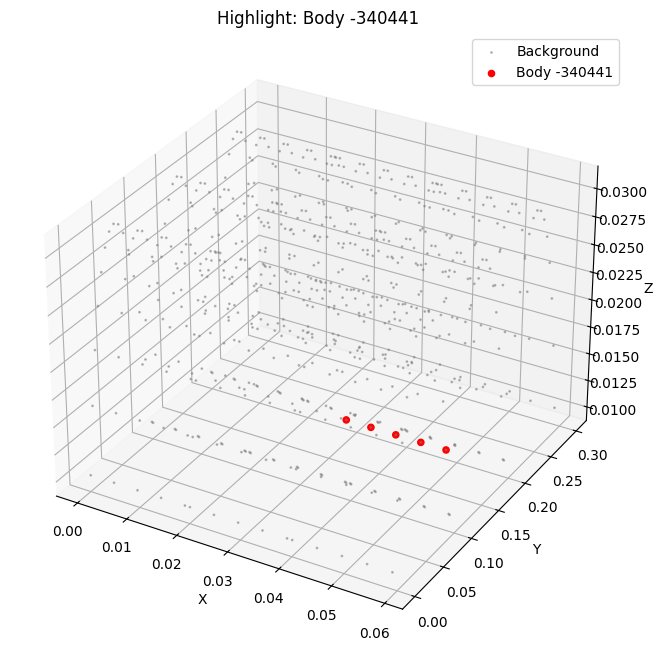

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ================= 1. 读取与处理数据 =================
# 读取坐标文件
df_coords = pd.read_csv('matched_nodes_coordinates.txt', sep='\t')
df_coords.columns = [c.strip() for c in df_coords.columns]

# 读取映射文件
df_map = pd.read_csv('node_solid_map.txt', sep=',', skipinitialspace=True)
df_map.columns = [c.strip() for c in df_map.columns]

# 统一数据类型
df_coords['Node'] = df_coords['Node'].astype(int)
df_map['NodeID'] = df_map['NodeID'].astype(int)

# 合并两个表格
df_merged = pd.merge(df_coords, df_map, left_on='Node', right_on='NodeID', how='inner')

# 按 BodyID 排序
df_merged = df_merged.sort_values(by='BodyID')

# 选取需要的列
output_df = df_merged[['BodyID', 'Node', 'X', 'Y', 'Z']]

# 保存为新 TXT 文件
output_df.to_csv('merged_body_nodes.txt', sep='\t', index=False)
print("✅ 文件已生成: merged_body_nodes.txt")

# ================= 2. 定义可视化函数 =================
def visualize_body(target_body_id):
    """
    输入: target_body_id (整数或浮点数)
    功能: 画出所有背景点(灰色)和指定BodyID的点(红色)
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 画背景 (使用原始坐标文件中的所有点)
    # alpha=0.05 让背景非常淡，不抢眼
    ax.scatter(df_coords['X'], df_coords['Y'], df_coords['Z'],
               c='grey', s=1, alpha=0.5, label='Background')

    # 2. 画目标 Body
    target_data = df_merged[df_merged['BodyID'] == target_body_id]

    if not target_data.empty:
        ax.scatter(target_data['X'], target_data['Y'], target_data['Z'],
                   c='red', s=20, alpha=1.0, label=f'Body {int(target_body_id)}')

        # 自动调整视角聚焦到目标物体
        mid_x = target_data['X'].mean()
        mid_y = target_data['Y'].mean()
        mid_z = target_data['Z'].mean()
        # 这里只是简单的聚焦，您可以手动旋转
        # ax.set_xlim(mid_x - 0.05, mid_x + 0.05)

        print(f"📍 已找到 Body {target_body_id}，包含 {len(target_data)} 个节点。")
    else:
        print(f"⚠️ 未找到 BodyID 为 {target_body_id} 的数据！请检查ID是否正确。")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Highlight: Body {target_body_id}')
    ax.legend()
    plt.show()

# ================= 3. 使用示例 =================
# 获取一个存在的 ID 来测试
sample_id = df_merged['BodyID'].values[0]

# 调用函数 (您可以把 sample_id 换成您想看的任何数字)
visualize_body(-340441)

#match I-beam bodys' names

1. 读取并计算 ID 中心...
   已计算 135 个内部 ID 的中心坐标。
2. 读取名字映射表... 成功加载 276 个部件名。
3. 正在进行几何匹配 (Matching Geometry)...
   匹配完成！共关联了 120 个部件。
📍 已定位部件: Body_4001 (ID: -340357)


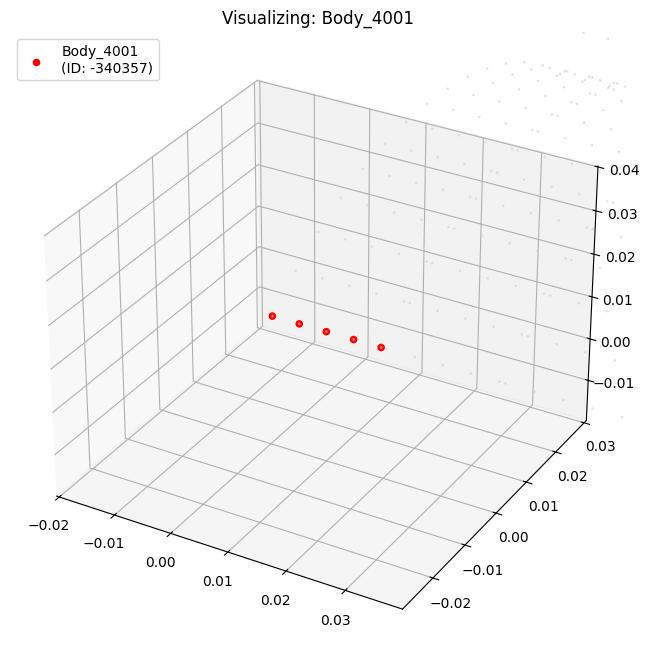

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ================= 配置 =================
# 1. APDL 导出的节点数据 (之前的 merged_body_nodes.txt)
#    如果您还没有这个文件，请用上一轮的脚本生成
data_file = 'merged_body_nodes.txt'

# 2. Workbench 导出的名字映射 (刚刚生成的 wb_name_map.txt)
name_file = 'wb_name_map.txt'

# ================= 1. 读取数据 =================
print("1. 读取并计算 ID 中心...")
# 读取节点数据
df_nodes = pd.read_csv(data_file, sep='\t')
df_nodes.columns = [c.strip() for c in df_nodes.columns]

# --- 核心步骤：计算每个 BodyID 的几何中心 ---
# 我们不需要知道 ID 是怎么生成的，算出它的中心在哪里就行
df_centers = df_nodes.groupby('BodyID')[['X', 'Y', 'Z']].mean().reset_index()
# 重命名，方便区分
df_centers.columns = ['BodyID', 'ID_X', 'ID_Y', 'ID_Z']

print(f"   已计算 {len(df_centers)} 个内部 ID 的中心坐标。")

# 读取名字映射文件
try:
    df_names = pd.read_csv(name_file, sep=',')
    print(f"2. 读取名字映射表... 成功加载 {len(df_names)} 个部件名。")
except:
    print("⚠️ 警告：找不到 wb_name_map.txt。无法显示名字，只能显示 ID。")
    df_names = pd.DataFrame()

# ================= 2. 匹配算法 (最近邻搜索) =================
# 创建一个字典： BodyID -> Name
id_to_name_map = {}

if not df_names.empty:
    print("3. 正在进行几何匹配 (Matching Geometry)...")
    from scipy.spatial import cKDTree

    # 构建 ID 中心点的 KD-Tree (快速搜索)
    id_points = df_centers[['ID_X', 'ID_Y', 'ID_Z']].values
    tree = cKDTree(id_points)

    # 遍历每一个 Workbench 的名字，去寻找最近的 ID
    wb_points = df_names[['Centroid_X', 'Centroid_Y', 'Centroid_Z']].values

    # 查询最近点 (返回 距离 和 索引)
    distances, indices = tree.query(wb_points)

    # 建立映射
    for i, idx in enumerate(indices):
        dist = distances[i]
        # 如果距离非常小（比如小于 1mm），说明匹配成功
        # 注意单位！如果您模型很大，这个阈值可能要调整
        if dist < 1:
            matched_id = df_centers.iloc[idx]['BodyID']
            part_name  = df_names.iloc[i]['Name']
            id_to_name_map[matched_id] = part_name
        else:
            print(f"   ⚠️ 未匹配到: {df_names.iloc[i]['Name']} (最近距离 {dist:.4f})")

print(f"   匹配完成！共关联了 {len(id_to_name_map)} 个部件。")

# ================= 3. 增强版可视化函数 =================
def find_and_plot(query):
    """
    query: 可以是 BodyID (数字)，也可以是名字 (字符串)
    """
    target_id = None
    target_name = "Unknown"

    # 判断用户输入的是名字还是ID
    if isinstance(query, str):
        # 此时 query 是名字，反向查找 ID
        # 这是一个简单的反向搜索
        for bid, name in id_to_name_map.items():
            if query in name: # 支持模糊搜索
                target_id = bid
                target_name = name
                break
        if target_id is None:
            print(f"❌ 找不到包含 '{query}' 的部件名字。")
            return
    else:
        # 此时 query 是数字 ID
        target_id = query
        target_name = id_to_name_map.get(target_id, "Unnamed Part")

    # 开始绘图
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 画背景 (灰色)
    ax.scatter(df_nodes['X'], df_nodes['Y'], df_nodes['Z'],
               c='lightgrey', s=1, alpha=0.5)

    # 画目标 (红色)
    target_data = df_nodes[df_nodes['BodyID'] == target_id]

    if not target_data.empty:
        ax.scatter(target_data['X'], target_data['Y'], target_data['Z'],
                   c='red', s=20, alpha=1.0, label=f'{target_name}\n(ID: {int(target_id)})')

        # 自动聚焦
        mid_x, mid_y, mid_z = target_data[['X','Y','Z']].mean()
        range_ = 0.03 # 视口范围
        ax.set_xlim(mid_x - range_, mid_x + range_)
        ax.set_ylim(mid_y - range_, mid_y + range_)
        ax.set_zlim(mid_z - range_, mid_z + range_)

        print(f"📍 已定位部件: {target_name} (ID: {int(target_id)})")
    else:
        print(f"❌ 数据中找不到 ID {target_id}")

    ax.legend()
    plt.title(f"Visualizing: {target_name}")
    plt.show()

# ================= 4. 测试 =================
# 示例：如果您有一个部件叫 "Beam_Front"，您可以直接搜名字
# find_and_plot("Beam_Front")

# 或者搜之前看到的 ID
sample_id = df_centers.iloc[0]['BodyID']
find_and_plot("Body_40")

In [15]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ================= 文件配置 =================
node_file = 'merged_body_nodes.txt'  # 包含 BodyID, Node, X, Y, Z
name_file = 'wb_name_map.txt'      # 包含 Name, Centroid_X, ...
output_file = 'final_named_structure.txt'
# ===========================================

print("1. 读取文件...")
try:
    # 读取节点数据
    df_nodes = pd.read_csv(node_file, sep='\t')
    df_nodes.columns = [c.strip() for c in df_nodes.columns]

    # 读取名字映射
    df_names = pd.read_csv(name_file, sep=',')
    df_names.columns = [c.strip() for c in df_names.columns]

    print(f"   节点数据: {len(df_nodes)} 行")
    print(f"   名字数据: {len(df_names)} 个部件")

except Exception as e:
    print(f"❌ 读取失败: {e}")
    print("   请确保 merged_body_nodes.txt 和 wb_name_map.txt 都在当前文件夹中！")
    exit()

print("2. 计算几何中心并匹配...")

# --- 步骤 A: 计算 APDL 数据的中心 ---
# 根据 BodyID 分组，计算每组的平均坐标 (X, Y, Z)
df_centers = df_nodes.groupby('BodyID')[['X', 'Y', 'Z']].mean().reset_index()
apdl_points = df_centers[['X', 'Y', 'Z']].values

# --- 步骤 B: 准备 Workbench 数据的中心 ---
wb_points = df_names[['Centroid_X', 'Centroid_Y', 'Centroid_Z']].values
wb_names = df_names['Name'].values

# --- 步骤 C: 建立 KD-Tree 进行最近邻搜索 ---
# 我们拿着 Workbench 的中心，去 APDL 的中心里找“最近的那个”
tree = cKDTree(apdl_points)

# query(查询点, k=1) 返回最近距离(dists)和对应的索引(idxs)
dists, idxs = tree.query(wb_points)

# --- 步骤 D: 建立映射字典 {BodyID : Name} ---
id_name_map = {}
matched_count = 0

# 设定一个容差 (例如 0.001 即 1mm，如果单位是m的话)
# 如果中心点距离小于这个值，认为是同一个物体
tolerance = 0.01

for i, idx in enumerate(idxs):
    dist = dists[i]
    if dist < tolerance:
        # 找到了！
        found_body_id = df_centers.iloc[idx]['BodyID']
        found_name = wb_names[i]
        id_name_map[found_body_id] = found_name
        matched_count += 1
    else:
        print(f"   ⚠️ 未匹配警告: {wb_names[i]} 距离最近的网格中心太远 ({dist:.4f})")

print(f"✅ 匹配完成！成功关联了 {matched_count} / {len(df_names)} 个部件。")

# ================= 3. 生成最终表格 =================
print("3. 生成导出数据...")

# 将名字映射回原始节点表
# map 函数会自动根据 BodyID 填入对应的 Name
df_nodes['BodyName'] = df_nodes['BodyID'].map(id_name_map)

# 过滤掉没匹配上的行 (dropna)
df_final = df_nodes.dropna(subset=['BodyName'])

# 按照 Name 排序，如果 Name 相同则按 Node 排序
df_final = df_final.sort_values(by=['BodyName', 'Node'])

# 整理列顺序
# 格式: Name, Node, X, Y, Z
output_df = df_final[['BodyName', 'Node', 'X', 'Y', 'Z']]

# 导出
output_df.to_csv(output_file, sep='\t', index=False)

print(f"🎉 文件已保存为: {output_file}")
print("-" * 30)
print("文件预览 (前 10 行):")
print(output_df.head(10))

1. 读取文件...
   节点数据: 1215 行
   名字数据: 276 个部件
2. 计算几何中心并匹配...
   ⚠️ 未匹配警告: Body_20 距离最近的网格中心太远 (0.0315)
   ⚠️ 未匹配警告: Body_23 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_26 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_29 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_32 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_35 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_38 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_41 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_44 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_47 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_50 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_53 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_56 距离最近的网格中心太远 (0.0174)
   ⚠️ 未匹配警告: Body_59 距离最近的网格中心太远 (0.0372)
   ⚠️ 未匹配警告: Body_62 距离最近的网格中心太远 (0.0372)
   ⚠️ 未匹配警告: Body_3599 距离最近的网格中心太远 (0.0140)
   ⚠️ 未匹配警告: Body_3602 距离最近的网格中心太远 (0.0140)
   ⚠️ 未匹配警告: Body_3605 距离最近的网格中心太远 (0.0140)
   ⚠️ 未匹配警告: Body_3608 距离最近的网格中心太远 (0.0140)
   ⚠️ 未匹配警告: Body_3611 距离最近的网格中心太远 (0.0140)
   ⚠️ 未匹配警告: Body_3614 距离最近的网格中心太远 (0.0140)
   ⚠️ 未匹配警告: Body_3617 距离最近的网格中心太远 (0.0140)
  

#find 18 missing I-beams

In [29]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os

# 1. 读取文件
file_name = 'matched_nodes_coordinates.txt'

try:
    # 尝试自动识别分隔符（兼容制表符 \t 和空格）
    # 如果你的文件是 tab 分隔，sep='\t'；如果是空格分隔，sep=None, engine='python'
    df = pd.read_csv(file_name, sep='\t')

    # 清理列名（去除首尾空格）
    df.columns = [c.strip() for c in df.columns]

    # 2. 智能识别 X, Y, Z, Node 列
    # 定义可能的列名映射（根据你提供的文件和你之前的报错信息）
    col_mapping = {}

    # 寻找 Node 列
    for col in df.columns:
        c_lower = col.lower()
        if 'node' in c_lower:
            col_mapping['Node'] = col
        elif 'x' in c_lower and 'location' in c_lower: # 匹配 "X Location (m)"
            col_mapping['X'] = col
        elif 'y' in c_lower and 'location' in c_lower:
            col_mapping['Y'] = col
        elif 'z' in c_lower and 'location' in c_lower:
            col_mapping['Z'] = col
        # 兼容简写情况
        elif col == 'X': col_mapping['X'] = 'X'
        elif col == 'Y': col_mapping['Y'] = 'Y'
        elif col == 'Z': col_mapping['Z'] = 'Z'

    # 检查是否找到了所有必要的列
    required_keys = ['Node', 'X', 'Y', 'Z']
    if all(k in col_mapping for k in required_keys):

        # 提取数据
        x_col = col_mapping['X']
        y_col = col_mapping['Y']
        z_col = col_mapping['Z']
        name_col = col_mapping['Node']

        # 过滤有效数据
        df_clean = df.dropna(subset=[x_col, y_col, z_col])
        print(f"成功识别列名! 正在绘制 {len(df_clean)} 个点...")

        # 3. 生成 3D 图
        fig = px.scatter_3d(
            df_clean,
            x=x_col,
            y=y_col,
            z=z_col,
            hover_name=name_col,
            title='Node Export 3D (True Scale)',
            opacity=0.8,
            width=1000,
            height=800
        )

        # 4. 【关键设置】还原坐标系，不缩放 (1:1:1 比例)
        fig.update_layout(
            scene=dict(
                aspectmode='data', # <--- 这就是你要的“不用缩放”，保持真实比例
                xaxis_title='X (m)',
                yaxis_title='Y (m)',
                zaxis_title='Z (m)'
            ),
            margin=dict(l=0, r=0, b=0, t=40) # 减少留白
        )

        # 设置点的大小
        fig.update_traces(marker=dict(size=2))

        fig.show()

    else:
        print("错误：无法自动识别 X, Y, Z 坐标列。")
        print(f"当前文件列名: {df.columns.tolist()}")
        print("请手动修改代码中的 x_col, y_col 变量。")

except Exception as e:
    print(f"发生错误: {e}")

成功识别列名! 正在绘制 675 个点...


In [44]:
import pandas as pd
import numpy as np

def extract_exact_5_nodes(node_file, start_nodes, radius=0.005, output_file="found_18beams.txt"):
    print(f"1. 读取文件: {node_file} ...")
    try:
        # 自动识别分隔符 (Tab 或 逗号)
        df = pd.read_csv(node_file, sep='\t', engine='python')
        df.columns = [c.strip() for c in df.columns]

        # 统一列名
        col_map = {'Node Number': 'Node', 'X Location (m)': 'X', 'Y Location (m)': 'Y', 'Z Location (m)': 'Z'}
        df = df.rename(columns=col_map)

        # 确保数据类型正确
        df['Node'] = df['Node'].astype(int)

    except Exception as e:
        print(f"❌ 读取文件失败: {e}")
        return

    all_beams_data = []
    # 用于记录已经被分配的节点ID，防止重复 (如果你希望允许共用节点，可以去掉这个集合)
    assigned_node_ids = set()

    print(f"2. 开始处理 {len(start_nodes)} 个横梁，每个横梁严格抓取 5 个点...")

    for start_id in start_nodes:
        # --- A. 获取起点信息 ---
        start_point = df[df['Node'] == start_id]
        if start_point.empty:
            print(f"   ⚠️ 起点 {start_id} 未找到，跳过。")
            continue

        x0 = start_point.iloc[0]['X']
        y0 = start_point.iloc[0]['Y']
        z0 = start_point.iloc[0]['Z']

        # --- B. 空间筛选 (粗筛) ---
        # 只筛选 Y 和 Z 在管道内的点，以及 X >= 起点的点
        # 半径设得很小 (例如 5mm)，保证不抓到隔壁排的梁
        mask = (
            (df['X'] >= x0 - 1e-4) &  # X 必须在起点之后 (允许微小误差)
            (df['Y'] >= y0 - radius) & (df['Y'] <= y0 + radius) &
            (df['Z'] >= z0 - radius) & (df['Z'] <= z0 + radius)
        )

        candidates = df[mask].copy()

        # --- C. 排序并截断 (精选) ---
        if len(candidates) > 0:
            # 1. 按 X 坐标从小到大排序 (即离起点从近到远)
            candidates = candidates.sort_values(by='X', ascending=True)

            # 2. 如果你需要严格排重 (一个点只能属于一个梁):
            # 过滤掉那些已经在 assigned_node_ids 里的点
            # candidates = candidates[~candidates['Node'].isin(assigned_node_ids)]

            # 3. 严格取前 5 个点
            top_5_nodes = candidates.head(5).copy()

            # 记录找到的点
            current_count = len(top_5_nodes)

            if current_count > 0:
                top_5_nodes['Belongs_To_Beam'] = start_id
                all_beams_data.append(top_5_nodes)

                # 更新已分配集合
                assigned_node_ids.update(top_5_nodes['Node'].tolist())

                status = "✅" if current_count == 5 else f"⚠️ (仅{current_count}个)"
                print(f"   - 梁起点 {start_id} -> 找到 {current_count} 个点 {status}")
            else:
                print(f"   - 梁起点 {start_id} -> 未找到有效的新节点 (可能都被前面的梁占用了)")
        else:
            print(f"   - 梁起点 {start_id} -> 搜索范围内无节点")

    # --- D. 保存 ---
    if all_beams_data:
        result_df = pd.concat(all_beams_data)

        # 再次检查是否有重复 (理论上逻辑控制了，但这步作为验证)
        duplicates = result_df[result_df.duplicated(subset=['Node'], keep=False)]
        if not duplicates.empty:
             print(f"\n⚠️ 警告: 依然发现 {len(duplicates)} 个重复节点 (请检查是否有点同时属于两个梁)")

        cols = ['Node', 'X', 'Y', 'Z', 'Belongs_To_Beam']
        result_df[cols].to_csv(output_file, sep='\t', index=False)
        print(f"\n🎉 处理完成! 共 {len(result_df)} 个节点。结果已保存至: {output_file}")
    else:
        print("\n❌ 未生成任何数据。")

# ==========================================
# 👇 用户配置
# ==========================================
my_start_ids = [
    24746, 24755, 24764, 24440, 24791, 24431,
    24782, 24377, 24773, 25142, 25133, 25124,
    25115, 25097, 25106, 25574, 25565, 25556
]

# 运行: 半径给小一点(0.005), 严格找5个
extract_exact_5_nodes(
    node_file='matched_nodes_coordinates.txt',
    start_nodes=my_start_ids,
    radius=0.0001
)

1. 读取文件: matched_nodes_coordinates.txt ...
2. 开始处理 18 个横梁，每个横梁严格抓取 5 个点...
   - 梁起点 24746 -> 找到 5 个点 ✅
   - 梁起点 24755 -> 找到 5 个点 ✅
   - 梁起点 24764 -> 找到 5 个点 ✅
   - 梁起点 24440 -> 找到 5 个点 ✅
   - 梁起点 24791 -> 找到 5 个点 ✅
   - 梁起点 24431 -> 找到 5 个点 ✅
   - 梁起点 24782 -> 找到 5 个点 ✅
   - 梁起点 24377 -> 找到 5 个点 ✅
   - 梁起点 24773 -> 找到 5 个点 ✅
   - 梁起点 25142 -> 找到 5 个点 ✅
   - 梁起点 25133 -> 找到 5 个点 ✅
   - 梁起点 25124 -> 找到 5 个点 ✅
   - 梁起点 25115 -> 找到 5 个点 ✅
   - 梁起点 25097 -> 找到 5 个点 ✅
   - 梁起点 25106 -> 找到 5 个点 ✅
   - 梁起点 25574 -> 找到 5 个点 ✅
   - 梁起点 25565 -> 找到 5 个点 ✅
   - 梁起点 25556 -> 找到 5 个点 ✅

🎉 处理完成! 共 90 个节点。结果已保存至: found_18beams.txt


In [43]:
import pandas as pd
import plotly.express as px

# 1. 读取文件
file_name = 'found_beams_strict.txt'

try:
    # 自动识别分隔符读取数据
    df = pd.read_csv(file_name, sep='\t')

    # 清理列名空格
    df.columns = [c.strip() for c in df.columns]

    print("原始数据列名:", df.columns.tolist())

    # 2. 识别关键列
    # 我们需要 Node, X, Y, Z。
    # 用户要求“删除第四列”，通常指删除多余的属性列（如 Belongs_To_Beam），
    # 但我们必须保留 X, Y, Z 才能画 3D 图。
    # 这里的逻辑是：只保留坐标和ID，忽略其他列带来的重复行。

    # 确保列名匹配 (兼容不同写法)
    col_map = {}
    for c in df.columns:
        if 'Node' in c: col_map['Node'] = c
        elif 'X' in c: col_map['X'] = c
        elif 'Y' in c: col_map['Y'] = c
        elif 'Z' in c: col_map['Z'] = c

    if len(col_map) >= 4:
        node_col = col_map['Node']
        x_col = col_map['X']
        y_col = col_map['Y']
        z_col = col_map['Z']

        # 3. 核心逻辑：标记重复点
        # 统计每个 Node 出现的次数
        # 如果一个节点在文件中出现 > 1 次，说明它是梁与梁的连接点（重复点）
        node_counts = df[node_col].value_counts()

        # 创建一个新列 'Type' 来区分颜色
        def get_node_type(node_id):
            if node_counts[node_id] > 1:
                return 'Shared Node (Red)' # 重复点
            else:
                return 'Single Node (Blue)' # 普通点

        df['Type'] = df[node_col].apply(get_node_type)

        # 4. 去重
        # 用户要求“重复的点画一次”。
        # 我们根据 Node ID 去重，保留第一条记录即可，因为坐标是一样的。
        df_unique = df.drop_duplicates(subset=[node_col])

        print(f"\n原始行数: {len(df)}")
        print(f"去重后绘图点数: {len(df_unique)}")
        print(f"其中重复点(红色)数量: {len(df_unique[df_unique['Type'] == 'Shared Node (Red)'])}")

        # 5. 画图
        # 指定颜色映射：Shared -> Red, Single -> Blue
        color_map = {
            'Shared Node (Red)': 'red',
            'Single Node (Blue)': 'blue'
        }

        fig = px.scatter_3d(
            df_unique,
            x=x_col,
            y=y_col,
            z=z_col,
            color='Type',             # 根据类型上色
            color_discrete_map=color_map, # 强制指定红色和蓝色
            hover_name=node_col,      # 鼠标悬停显示节点号
            title='Beam Nodes Visualization (Red = Duplicates/Junctions)',
            opacity=0.8,
            width=1000,
            height=800
        )

        # 6. 设置不缩放坐标轴 (1:1:1)
        fig.update_layout(
            scene=dict(
                aspectmode='data',    # 保持真实比例
                xaxis_title='X',
                yaxis_title='Y',
                zaxis_title='Z'
            )
        )

        # 调整点的大小
        fig.update_traces(marker=dict(size=3))

        fig.show()

    else:
        print("错误：无法找到 Node, X, Y, Z 列，请检查文件内容。")

except Exception as e:
    print(f"运行出错: {e}")

原始数据列名: ['Node', 'X', 'Y', 'Z', 'Belongs_To_Beam']

原始行数: 90
去重后绘图点数: 90
其中重复点(红色)数量: 0


In [45]:
import pandas as pd

def format_beam_file(input_file, output_file):
    # 1. 读取之前的搜索结果
    df = pd.read_csv(input_file, sep='\t')

    # 2. 创建映射关系：将原本的起点ID映射为 'body 1', 'body 2' ...
    # unique() 会按照出现的顺序提取ID，所以 body 1 对应列表里的第一个梁
    unique_ids = df['Belongs_To_Beam'].unique()

    # 生成字典: {24746: 'body 1', 24755: 'body 2', ...}
    id_map = {uid: f"body {i+1}" for i, uid in enumerate(unique_ids)}

    # 3. 应用映射并改名
    df['BodyName'] = df['Belongs_To_Beam'].map(id_map)

    # 4. 调整列的顺序，把 BodyName 放到第一位
    # 假设你还需要 Node, X, Y, Z
    cols = ['BodyName', 'Node', 'X', 'Y', 'Z']
    df_final = df[cols]

    # 5. 保存
    df_final.to_csv(output_file, sep='\t', index=False)
    print(f"✅ 处理完成！")
    print(f"   - 列顺序已调整: {cols}")
    print(f"   - BodyName 已重命名 (body 1 - body {len(unique_ids)})")
    print(f"   - 文件已保存为: {output_file}")

    # 打印前几行预览
    print("\n前10行数据预览:")
    print(df_final.head(10))

# 运行处理
format_beam_file('found_18beams.txt', 'final_18_beams_formatted.txt')

✅ 处理完成！
   - 列顺序已调整: ['BodyName', 'Node', 'X', 'Y', 'Z']
   - BodyName 已重命名 (body 1 - body 18)
   - 文件已保存为: final_18_beams_formatted.txt

前10行数据预览:
  BodyName   Node        X        Y         Z
0   body 1  24746  0.00000  0.00081  0.010193
1   body 1  24749  0.00475  0.00081  0.010193
2   body 1  24748  0.00950  0.00081  0.010193
3   body 1  24747  0.01425  0.00081  0.010193
4   body 1  24745  0.01900  0.00081  0.010193
5   body 2  24755  0.02000  0.00081  0.010193
6   body 2  24758  0.02475  0.00081  0.010193
7   body 2  24757  0.02950  0.00081  0.010193
8   body 2  24756  0.03425  0.00081  0.010193
9   body 2  24754  0.03900  0.00081  0.010193


In [46]:
import pandas as pd

# 读取两个文件
# 使用 tab 分隔符读取
df_18_beams = pd.read_csv('final_18_beams_formatted.txt', sep='\t')
df_structure = pd.read_csv('final_named_structure.txt', sep='\t')

# 检查两个 DataFrame 的列名是否一致
print("18 beams columns:", df_18_beams.columns.tolist())
print("Structure columns:", df_structure.columns.tolist())

# 确保列名一致以便合并
# 如果列名有细微差别（比如空格），在这里统一
df_18_beams.columns = [c.strip() for c in df_18_beams.columns]
df_structure.columns = [c.strip() for c in df_structure.columns]

# 合并两个 DataFrame
# ignore_index=True 重新生成索引
df_combined = pd.concat([df_structure, df_18_beams], ignore_index=True)

# 保存到新文件
output_filename = 'final-named-structure(new).txt'
df_combined.to_csv(output_filename, sep='\t', index=False)

print(f"合并完成，共 {len(df_combined)} 行数据。")
print(f"已保存至: {output_filename}")

18 beams columns: ['BodyName', 'Node', 'X', 'Y', 'Z']
Structure columns: ['BodyName', 'Node', 'X', 'Y', 'Z']
合并完成，共 1143 行数据。
已保存至: final-named-structure(new).txt


#FINAL result

In [49]:
import pandas as pd
import plotly.express as px

# ================= 文件名 =================
filename = "final-named-structure(new).txt"
# ========================================

try:
    print("1. 读取数据...")
    df = pd.read_csv(filename, sep='\t')
    # 清理列名空格
    df.columns = [c.strip() for c in df.columns]

    print(f"   成功读取 {len(df)} 个节点。")
    print(f"   包含部件数量: {len(df['BodyName'].unique())}")

    print("2. 生成交互式图表...")

    # 使用 Plotly Express 创建 3D 散点图
    fig = px.scatter_3d(
        df,
        x='X',
        y='Y',
        z='Z',
        color='BodyName',          # 根据名字自动着色
        hover_name='BodyName',     # 鼠标悬停时的大标题
        hover_data={               # 定制悬停显示的详细信息
            'BodyName': False,     # 标题已显示，这里不重复
            'Node': True,          # 显示节点号
            'X': True,             # 显示坐标
            'Y': True,
            'Z': True
        },
        title='Interactive Structure Visualization (Hover to see Name)',
        opacity=1.0,               # 点的不透明度
        width=1200,                # 图表宽度
        height=900                 # 图表高度
    )

    # 优化显示效果
    fig.update_traces(marker=dict(size=4)) # 把点稍微调大一点，更好选中

    # 如果部件太多（超过20个），隐藏图例防止挡住画面
    if len(df['BodyName'].unique()) > 20:
        fig.update_layout(showlegend=False)
        print("   (提示：部件较多，已自动隐藏图例以保持视野清晰)")

    # 锁定比例，防止模型被压扁
    fig.update_layout(scene=dict(aspectmode='data'))

    # 鼠标悬停样式优化
    fig.update_layout(hoverlabel=dict(
        bgcolor="white",
        font_size=14,
        font_family="Rockwell"
    ))

    print("🎉 图表已生成！请在下方查看。")
    fig.show()

except Exception as e:
    print(f"❌ 发生错误: {e}")

1. 读取数据...
   成功读取 1143 个节点。
   包含部件数量: 135
2. 生成交互式图表...
   (提示：部件较多，已自动隐藏图例以保持视野清晰)
🎉 图表已生成！请在下方查看。
